<a href="https://colab.research.google.com/github/Muzzikon/WWML/blob/main/WWML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# The first 3 weeks

In [1]:
import random
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
# Генерация данных

def generate_apartment():
    location = random.randint(1, 10)
    rooms = random.randint(1, 6)
    distance = round(random.uniform(0.5, 25), 2)
    floor = random.randint(1, 25)

    mean_area = 50  # Средняя площадь
    std_area = 20   # Стандартное отклонение площади
    S = round(np.random.normal(mean_area, std_area), 1)
    S = max(S, 10)  # Площадь не может быть меньше 10 м^2

    base_m2_price = 150000
    loc_coeff = 1.7 - (location / 10)
    dist_coeff = max(0.6, 1 - (distance / 50))
    final_m2_price = base_m2_price * loc_coeff * dist_coeff

    total_price = (int((S * final_m2_price) * random.uniform(0.95, 1.05)) // 10000) * 10000
    total_vis_price = str(total_price)[:-6] + '.' + str(total_price)[-6:-3] + '.' + str(total_price)[-4:-1]
    information = {
        "район": location,
        "площадь m^2": S,
        "кол-во комнат": rooms,
        "удаленность от центра (км)": distance,
        "этаж": floor,
        "цена": total_price}

    return information

# Создание файла с данными
def generate_data(n=1000):
    data = [generate_apartment() for _ in range(n)]
    return pd.DataFrame(data)

if __name__ == "__main__":
    data_set = generate_data()
    data_set.to_csv('dataset.csv', index=False)

In [3]:
# Показ данных

data_set = generate_data(1000)  # Генерируем сразу 1000 записей
pd.set_option('display.expand_frame_repr', False)  # Запретить перенос строк
pd.set_option('display.max_columns', None)       # Показывать все столбцы

print (data_set)

     район  площадь m^2  кол-во комнат  удаленность от центра (км)  этаж      цена
0        3         33.8              1                        3.89    13   6470000
1        3         26.6              2                        9.65    20   4470000
2       10         30.1              4                       15.75    12   2190000
3        9         31.1              1                        1.03    21   3580000
4        7         51.0              1                        4.68    22   6900000
..     ...          ...            ...                         ...   ...       ...
995      5         52.7              1                        2.43    13   9000000
996      3         10.0              4                       13.78     2   1510000
997      5         73.7              3                        6.67    19  11090000
998      1         63.3              4                        6.17    25  13830000
999      8         91.7              6                       23.44    17   7650000

[10

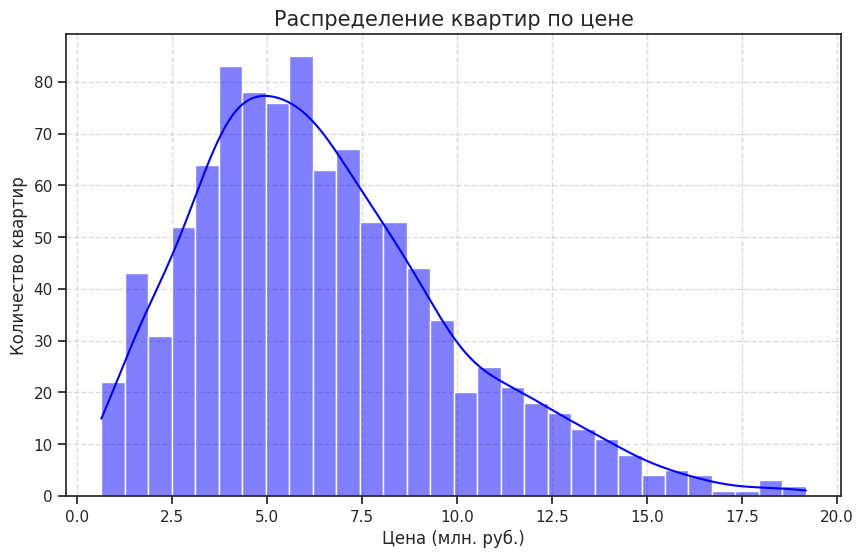

In [4]:
# Гистограмма

sns.set_theme(style="ticks", palette="pastel")
plt.figure(figsize=(10,6))
prices_in_millions = data_set["цена"] / 1_000_000
sns.histplot(prices_in_millions, bins=30, kde=True, color='blue')
plt.title("Распределение квартир по цене",fontsize=15)
plt.xlabel("Цена (млн. руб.)", fontsize=12)
plt.ylabel("Количество квартир", fontsize=12)
plt.ticklabel_format(style='plain', axis='x')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

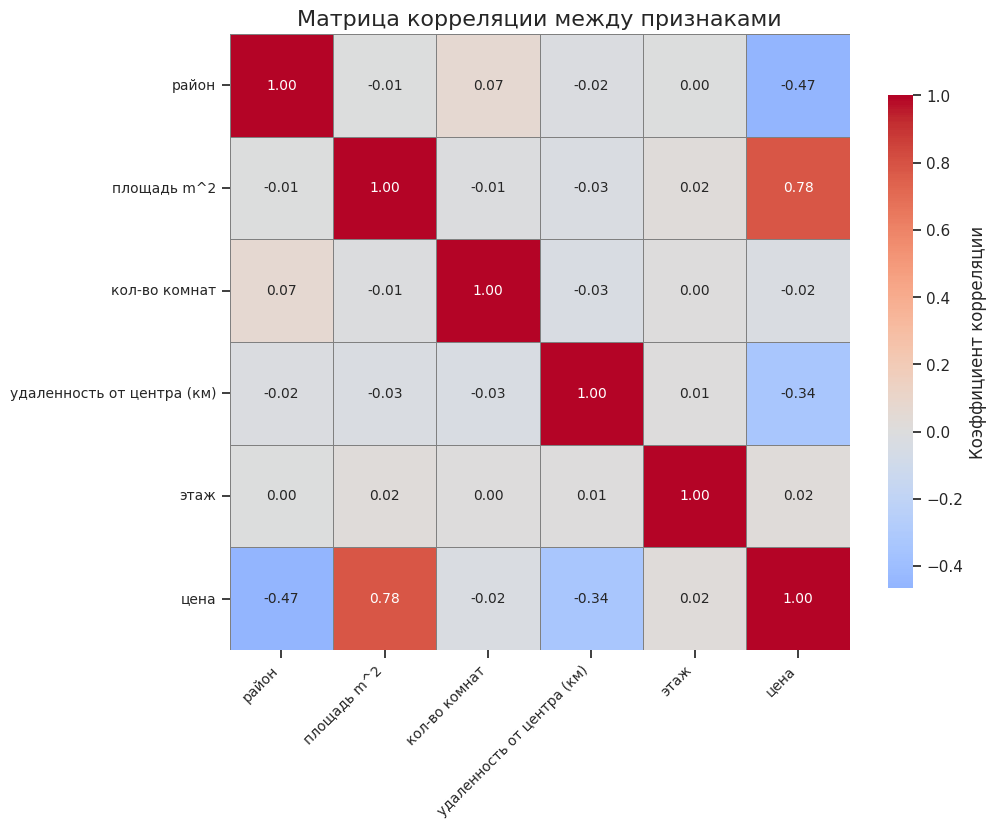

In [5]:
# Матрица корреляции

correlation_matrix = data_set.corr()

plt.figure(figsize=(10, 8))

sns.heatmap(correlation_matrix,
            annot=True,
            cmap='coolwarm',
            center=0,
            cbar_kws={"shrink": 0.8, "label": "Коэффициент корреляции"},
            fmt='.2f',
            annot_kws={'size': 10},

            linewidths=0.5,
            linecolor='gray')

plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)

plt.title("Матрица корреляции между признаками", fontsize=16)
plt.show()

# The second 3 weeks

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import joblib

In [9]:
# Обучение модели

# Загрузка данных
df = pd.read_csv("dataset.csv")

# Признаки и целевая переменная
X = df.drop(columns=["цена"])
y = df["цена"]

# Одинаковое разбиение для честного сравнения
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Две модели
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial(2) + Ridge": Pipeline([
        ("poly", PolynomialFeatures(degree=2, include_bias=False)),
        ("ridge", Ridge(alpha=1.0))
    ])
}

# Обучение и сравнение
results = []
trained_models = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    results.append({
        "Модель": name,
        "MAE": round(mae, 2),
        "RMSE": round(rmse, 2),
        "R2": round(r2, 4)
    })

    trained_models[name] = model

results_df = pd.DataFrame(results).sort_values(by="MAE").reset_index(drop=True)
results_df

,Модель,MAE,RMSE,R2
0,Polynomial(2) + Ridge,205723.53,267434.67,0.9938
1,Linear Regression,622038.14,833478.83,0.9398


In [10]:
best_model_name = results_df.loc[0, "Модель"]
print("Лучшая модель по MAE:", best_model_name)

Лучшая модель по MAE: Polynomial(2) + Ridge


In [11]:
best_model = trained_models[best_model_name]
joblib.dump(best_model, "price_prediction_model.pkl")
print("Модель сохранена в файл: price_prediction_model.pkl")

Модель сохранена в файл: price_prediction_model.pkl
